In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Cargar datos REALES (no sintéticos como el tutorial)
data = pd.read_csv('../data/raw/train_revised.csv')

print("Shape:", data.shape)
print("\nPrimeras filas:")
data.head()

Shape: (51645, 10)

Primeras filas:


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


Celda 2

In [6]:
# Convertir fecha y hora
data['travel_date'] = pd.to_datetime(data['travel_date'], dayfirst=True)
data['day_of_week'] = data['travel_date'].dt.dayofweek
data['month']       = data['travel_date'].dt.month
data['hour']        = pd.to_datetime(data['travel_time'], format='%H:%M').dt.hour

# Variable objetivo: tickets vendidos por ride_id
# Contamos cuántos registros (tickets) tiene cada ride_id
tickets_por_viaje = data.groupby('ride_id').agg(
    number_of_tickets = ('seat_number', 'count'),
    travel_date       = ('travel_date', 'first'),
    travel_time       = ('travel_time', 'first'),
    travel_from       = ('travel_from', 'first'),
    travel_to         = ('travel_to',   'first'),
    car_type          = ('car_type',    'first'),
    max_capacity      = ('max_capacity','first'),
    payment_method    = ('payment_method','first'),
    day_of_week       = ('day_of_week', 'first'),
    month             = ('month',       'first'),
    hour              = ('hour',        'first'),
).reset_index()

print("Viajes únicos:", tickets_por_viaje.shape[0])
print("\nEstadísticas de tickets vendidos por viaje:")
print(tickets_por_viaje['number_of_tickets'].describe().round(2))

Viajes únicos: 6249

Estadísticas de tickets vendidos por viaje:
count    6249.00
mean        8.26
std         8.63
min         1.00
25%         2.00
50%         7.00
75%        11.00
max        50.00
Name: number_of_tickets, dtype: float64


celda 3

In [9]:
# Features y target
X = tickets_por_viaje.drop(columns=['ride_id', 'number_of_tickets', 
                                     'travel_date', 'travel_time'])
y = tickets_por_viaje['number_of_tickets']

# Columnas categóricas y numéricas
categorical_features = ['payment_method', 'travel_from', 'travel_to', 'car_type']
numerical_features   = ['max_capacity', 'day_of_week', 'month', 'hour']

# Preprocesamiento — handle_unknown='ignore' maneja categorías raras
categorical_transformer = OneHotEncoder(drop='first', 
                                         sparse_output=False,
                                         handle_unknown='ignore')  # ← fix
numerical_transformer   = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features),
])

print("✓ Preprocesador listo")
print("Features numéricas:", numerical_features)
print("Features categóricas:", categorical_features)

✓ Preprocesador listo
Features numéricas: ['max_capacity', 'day_of_week', 'month', 'hour']
Features categóricas: ['payment_method', 'travel_from', 'travel_to', 'car_type']


celda 4

In [10]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline con Random Forest (igual que el tutorial)
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Métricas
mse  = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_rf)
r2   = r2_score(y_test, y_pred_rf)

print("=== RESULTADOS RANDOM FOREST ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== RESULTADOS RANDOM FOREST ===
MSE:  50.9940
RMSE: 7.1410
MAE:  4.3865
R²:   0.3721


celda 5

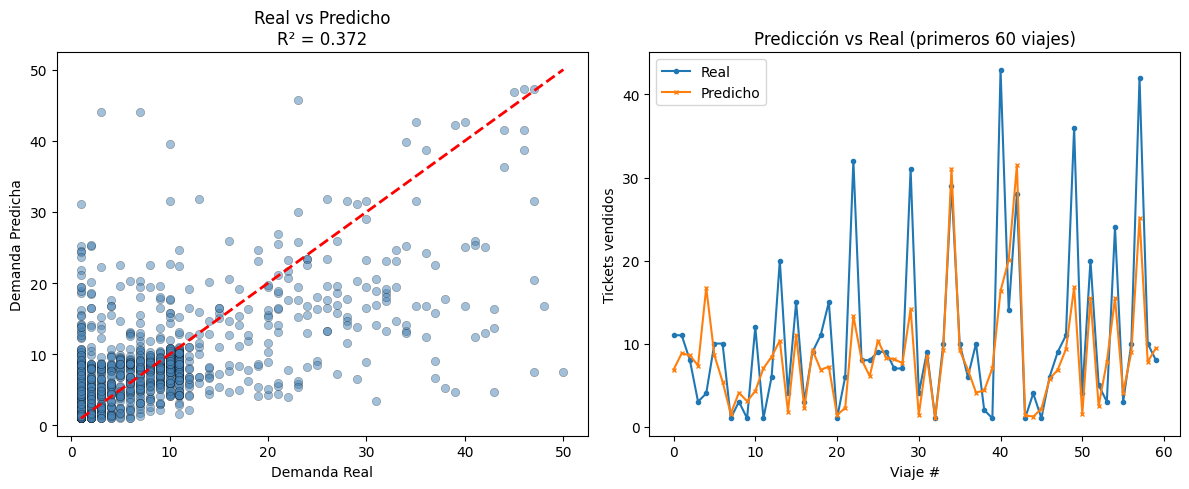

✓ Gráfica guardada


In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='steelblue', edgecolors='k', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Demanda Real')
plt.ylabel('Demanda Predicha')
plt.title(f'Real vs Predicho\nR² = {r2:.3f}')

plt.subplot(1, 2, 2)
indices = range(len(y_test[:60]))
plt.plot(indices, y_test.values[:60], label='Real', marker='o', markersize=3)
plt.plot(indices, y_pred_rf[:60],    label='Predicho', marker='x', markersize=3)
plt.xlabel('Viaje #')
plt.ylabel('Tickets vendidos')
plt.title('Predicción vs Real (primeros 60 viajes)')
plt.legend()

plt.tight_layout()
plt.savefig('../reports/figures/prediccion_vs_real.png', dpi=150)
plt.show()
print("✓ Gráfica guardada")

celda 6

In [12]:
joblib.dump(pipeline_rf, '../models/modelo_rf.pkl')
print("✓ Modelo guardado en models/modelo_rf.pkl")

# Guardar métricas
import json
metricas = {'MSE': round(mse,4), 'RMSE': round(rmse,4), 
            'MAE': round(mae,4), 'R2': round(r2,4)}
with open('../reports/metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print("✓ Métricas guardadas en reports/metricas.json")
print("\nMétricas:", metricas)


✓ Modelo guardado en models/modelo_rf.pkl
✓ Métricas guardadas en reports/metricas.json

Métricas: {'MSE': 50.994, 'RMSE': 7.141, 'MAE': 4.3865, 'R2': 0.3721}


celda 7

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, 
                                         learning_rate=0.05,
                                         max_depth=4,
                                         random_state=42))
])

pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)

mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("=== RESULTADOS GRADIENT BOOSTING ===")
print(f"MSE:  {mse_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print(f"MAE:  {mae_gb:.4f}")
print(f"R²:   {r2_gb:.4f}")

=== RESULTADOS GRADIENT BOOSTING ===
MSE:  43.2519
RMSE: 6.5766
MAE:  4.4150
R²:   0.4674


celda 8

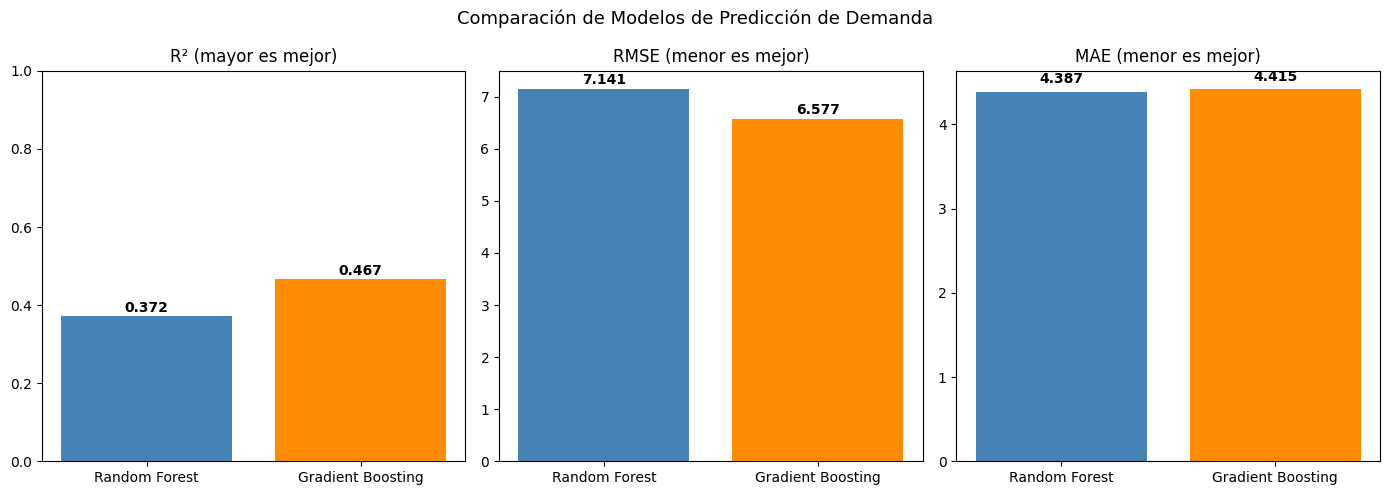

In [14]:
modelos = ['Random Forest', 'Gradient Boosting']
r2s     = [r2, r2_gb]
rmses   = [rmse, rmse_gb]
maes    = [mae, mae_gb]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(modelos, r2s, color=['steelblue', 'darkorange'])
axes[0].set_title('R² (mayor es mejor)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2s):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(modelos, rmses, color=['steelblue', 'darkorange'])
axes[1].set_title('RMSE (menor es mejor)')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(modelos, maes, color=['steelblue', 'darkorange'])
axes[2].set_title('MAE (menor es mejor)')
for i, v in enumerate(maes):
    axes[2].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos de Predicción de Demanda', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/comparacion_modelos.png', dpi=150)
plt.show()

celda 9

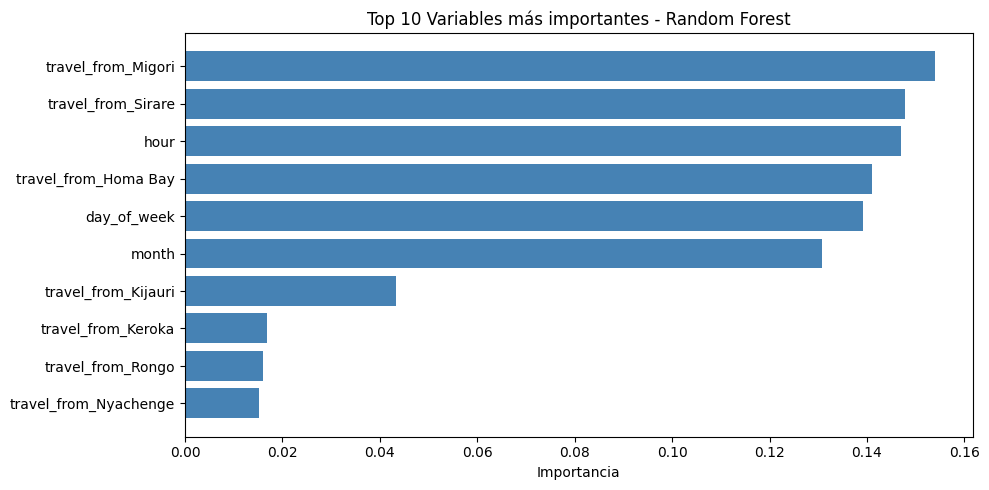

In [15]:
# Nombres de features después del encoding
cat_feature_names = pipeline_rf.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(cat_feature_names)

# Importancias del Random Forest
importancias = pipeline_rf.named_steps['model'].feature_importances_

# Top 10
indices = np.argsort(importancias)[::-1][:10]
top_features = [all_features[i] for i in indices]
top_importancias = importancias[indices]

plt.figure(figsize=(10, 5))
plt.barh(top_features[::-1], top_importancias[::-1], color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 10 Variables más importantes - Random Forest')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

celda 10

In [16]:
# Guardar el mejor modelo (el que tenga mejor R²)
mejor_modelo = pipeline_gb if r2_gb > r2 else pipeline_rf
mejor_nombre = 'Gradient Boosting' if r2_gb > r2 else 'Random Forest'

joblib.dump(mejor_modelo, '../models/mejor_modelo.pkl')
print(f"✓ Mejor modelo guardado: {mejor_nombre}")

# Actualizar métricas
import json
metricas_completas = {
    'random_forest':      {'MSE': round(mse,4),    'RMSE': round(rmse,4),    'MAE': round(mae,4),    'R2': round(r2,4)},
    'gradient_boosting':  {'MSE': round(mse_gb,4), 'RMSE': round(rmse_gb,4), 'MAE': round(mae_gb,4), 'R2': round(r2_gb,4)},
    'mejor_modelo': mejor_nombre
}
with open('../reports/metricas.json', 'w') as f:
    json.dump(metricas_completas, f, indent=2)

print("\n=== RESUMEN FINAL ===")
print(f"Random Forest    → R²: {r2:.3f} | RMSE: {rmse:.3f}")
print(f"Gradient Boosting → R²: {r2_gb:.3f} | RMSE: {rmse_gb:.3f}")
print(f"\nMejor modelo: {mejor_nombre}")

✓ Mejor modelo guardado: Gradient Boosting

=== RESUMEN FINAL ===
Random Forest    → R²: 0.372 | RMSE: 7.141
Gradient Boosting → R²: 0.467 | RMSE: 6.577

Mejor modelo: Gradient Boosting
